### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = pd.read_csv('drive/MyDrive/all_data/5.1/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:
na_data = data.isna().sum()
na_data = na_data.reset_index()
na_data = na_data.rename(columns={'index': 'column', 0: 'na_count'})
na_data


total = data.shape[0]
na_data['na_percent'] = (na_data['na_count'] / total) * 100
na_data_nulls = na_data[na_data['na_count'] > 0]
na_data_nulls


,column,na_count,na_percent
14,car,12576,99.148534
15,Bar,107,0.843582
16,CoffeeHouse,217,1.710817
17,CarryAway,151,1.190476
18,RestaurantLessThan20,130,1.024913
19,Restaurant20To50,189,1.490066


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [7]:
for col in na_data_nulls['column']:
  print(f'===={col}====')
  print(data[col].value_counts(dropna=False))
  print()

====car====
car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64

====Bar====
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64

====CoffeeHouse====
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64

====CarryAway====
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64

====RestaurantLessThan20====
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64

====Restaurant20To50====
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8

3. Decide what to do about your missing data -- drop, replace, other...

##Data Preprocessing & Cleanup

From the data collected above I can make a decision of what to do with the invalid data.

####Null Data Counts

```
    column 	na_count 	na_percent
14 	car 	              12576    99.1485
15 	Bar 	                107 	0.8436
16 	CoffeeHouse 	        217 	1.7108
17 	CarryAway 	            151 	1.1905
18 	RestaurantLessThan20 	130 	1.0249
19 	Restaurant20To50 	    189 	1.4901
```

Right away, one can see that most of the invalid records represent less than 2% of the total data, except for the `car` column. Let's put that one aside and look at the remaining ones.

The other columns `Bar`, `CoffeeHouse` etc all represent average number of visits to that a respondent has. Looking at the responses, the answers vary from `never` to `>8`. I can intrepret this to mean average **per week** as the answers then range from 0 < x <= 1+ visits per day.

From a respondent's POV, they might have not answered the question because i) they did not know what to answer i.e. the question was ambiguous or ii) they abstained from answering. I reach this conclusion because there are responses for 0 times.

If the occurences of data were higher like say 10%, I might've distributed them based on the average of the other responses, or based on some other parameter; for example, I could correlate `Restaurant20To50` with `income` in the original data set and distribute it that way. I could also keep the data as nulls in one column; there may still have usable data in the other, and I could ignore the nulls at the time of computation. However, for the sake of simplicity and due to the very low occurence of invalid data, I am just going to remove this data.

For the `car` column though, it is interesting because the vast majority >99% is null. Taking a closer look at the unique values, one can see

```
====car====
car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
```
It is odd that for the `car` column, there is no `car` value; in fact, the results seem to indicate that these are all non-cars or in the last case, cars that do not have "Onstar". Looking up this company at https://www.onstar.com/ shows connected vehicles service. It is safe to assume then, that the null values are just various types of cars that may have been removed for anonymity or some other reason e.g. the question may have been "indicate mode of transport if you don't use an OnStar car". I feel comfortable filling these values with just "car".

In [8]:
data_cleaned = data
data_cleaned['car'] = data_cleaned['car'].fillna('car')
data_cleaned = data_cleaned.dropna()

In [9]:
## Let's rename the column for readability
data_cleaned = data_cleaned.rename(columns={'Y': "AcceptedCoupon_Raw"})
data_cleaned.loc[:, "Accepted?"] = data_cleaned["AcceptedCoupon_Raw"].map({0: "no", 1: "yes"})
data_cleaned

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,AcceptedCoupon_Raw,Accepted?
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,yes
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,0,no
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,yes
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,0,no
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,1~3,4~8,1~3,1,0,0,1,0,1,yes
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,1~3,4~8,1~3,1,0,0,0,1,1,yes
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,1~3,4~8,1~3,1,0,0,1,0,0,no
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,1~3,4~8,1~3,1,1,1,0,1,0,no


4. What proportion of the total observations chose to accept the coupon?



In [10]:
data_cleaned['AcceptedCoupon_Raw'].value_counts(normalize=True) * 100

,proportion
AcceptedCoupon_Raw,
1,56.933521
0,43.066479


**56.93%** of respondents would accept the coupon

5. Use a bar plot to visualize the `coupon` column.

In [11]:
coupon = data_cleaned['coupon'].value_counts()
coupon = coupon.reset_index()
coupon

,coupon,count
0,Coffee House,3816
1,Restaurant(<20),2653
2,Carry out & Take away,2280
3,Bar,1913
4,Restaurant(20-50),1417


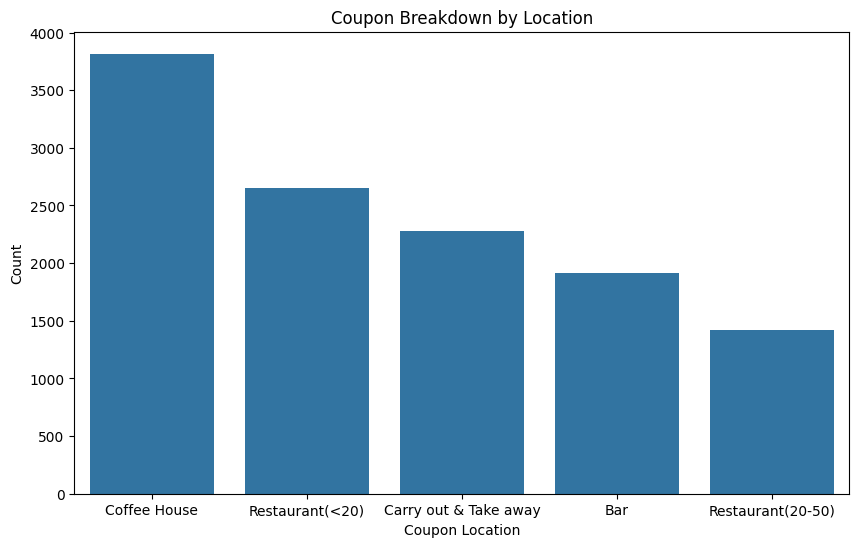

In [12]:
plt.figure(figsize=(10, 6)) # Width, Height in inches
sns.barplot(x='coupon', y='count', data=coupon)
plt.title('Coupon Breakdown by Location')
plt.xlabel('Coupon Location')
plt.ylabel('Count')
plt.show()

In [13]:
# Let's examine the accepted coupon breakdown
accepted_coupon_df = data_cleaned.query('AcceptedCoupon_Raw == 1')
accepted_coupon_df.sample(3)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,AcceptedCoupon_Raw,Accepted?
3989,Home,Alone,Sunny,55,6PM,Bar,1d,Male,36,Single,...,gt8,gt8,1~3,1,0,0,1,0,1,yes
12048,No Urgent Place,Friend(s),Snowy,30,2PM,Restaurant(<20),1d,Male,46,Married partner,...,1~3,1~3,1~3,1,0,0,0,1,1,yes
10103,No Urgent Place,Alone,Sunny,80,10PM,Restaurant(<20),1d,Female,36,Married partner,...,4~8,4~8,1~3,1,0,0,0,1,1,yes


In [14]:
accepted_coupon_df_total = accepted_coupon_df.shape[0]
accepted_coupon_df_total

6877

In [15]:
accepted_coupon_breakdown = accepted_coupon_df['coupon'].value_counts().reset_index()
accepted_coupon_breakdown

,coupon,count
0,Coffee House,1894
1,Restaurant(<20),1881
2,Carry out & Take away,1682
3,Bar,788
4,Restaurant(20-50),632


In [16]:
def raw_normalized_counts_label(percent):
    val = int(round(percent * accepted_coupon_df_total / 100.0))
    return f'{val:,}\n({percent:.1f}%)'


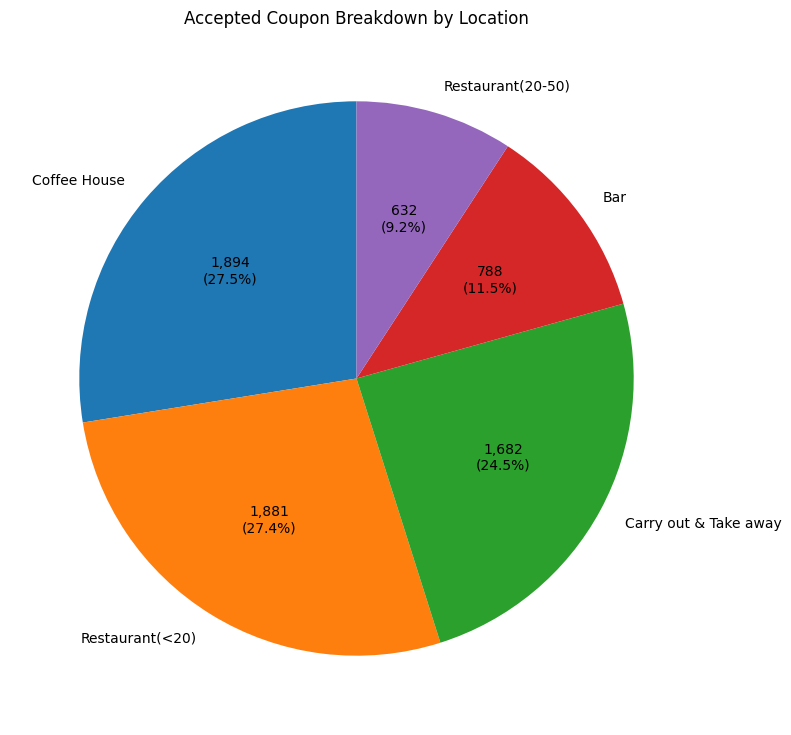

In [17]:
plt.figure(figsize=(15, 9)) # Width, Height in inches
pie_plot = plt.gcf()
plt.pie(
    accepted_coupon_breakdown['count'],
    labels=accepted_coupon_breakdown['coupon'],
    autopct=raw_normalized_counts_label,
    startangle=90
)
plt.title("Accepted Coupon Breakdown by Location")
plt.show()


So out of the almost 57% of people who accepted the coupon, **27.5%** of those went to the coffee house. Therefore, `57% x 27.5% = 15.7%` of all coupons were `accepted & coffee house`. This is the largest share, slightly edging out `restaurant<20`

6. Use a histogram to visualize the temperature column.

In [18]:
t_col = data_cleaned["temperature"]
print(
    pd.concat(
    [t_col.value_counts(), t_col.value_counts(normalize=True)*100],
    axis=1,
    keys=["count", "percentage"],
  )
)

             count  percentage
temperature                   
80            6222   51.510887
55            3662   30.317079
30            2195   18.172034


Before plotting, let's revisit the temperature data.

The prompt mentions that customers were given only 3 values to choose from. This is confirmed when examining the data's unique values

```
             count  percentage
temperature                   
80            6222   51.510887
55            3662   30.317079
30            2195   18.172034

```

So all respondents only selected one value among three, rather than a free entry, and a little more than half selected `80`. When I plot this data, one should expect to see distinct lines for each temperature value rather than a gradient.


In [19]:
t_accepted = data_cleaned[['temperature', 'Accepted?']].copy()
t_accepted

,temperature,Accepted?
22,55,yes
23,80,no
24,80,yes
25,80,no
26,80,no
...,...,...
12679,55,yes
12680,55,yes
12681,30,no
12682,30,no


In [20]:
# initial analisys - get raw counts and percentages by (temperature, Accepted?)
temp_counts_raw = t_accepted.groupby('temperature')['Accepted?'].value_counts()
temp_counts_norm = t_accepted.groupby('temperature')['Accepted?'].value_counts(normalize=True) * 100

# Combine into a single, clean table
t_accepted_summary = pd.concat([temp_counts_raw, temp_counts_norm.round(1)], axis=1, keys=['Count', 'Percentage (%)'])
print(t_accepted_summary)


                       Count  Percentage (%)
temperature Accepted?                       
30          yes         1179            53.7
            no          1016            46.3
55          yes         1967            53.7
            no          1695            46.3
80          yes         3731            60.0
            no          2491            40.0


In [21]:
custom_colors = {
    'yes': '#2ecc71', # green
    'no': '#e74c3c'   # red
}

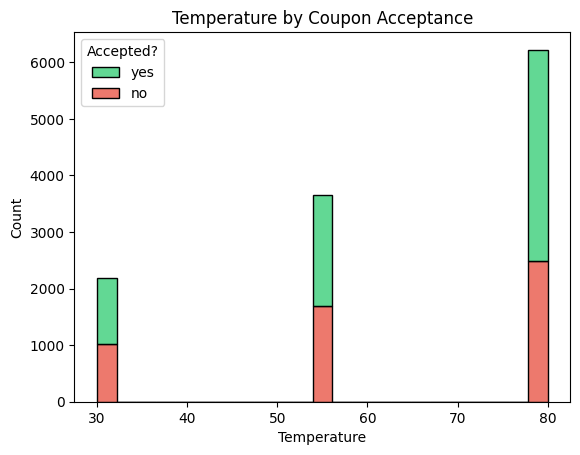

In [22]:
sns.histplot(
    data=t_accepted,
    x=t_accepted['temperature'],
    hue='Accepted?',
    palette=custom_colors,
    multiple='stack' # new param
)

plt.title('Temperature by Coupon Acceptance')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()


Interesting to note that the ratio of rejections increased when the weather got better. From the chart as well as the initial analysis one can see that the accepted values are more than `50% Yes` for all temperature ranges.

The original histplot looked like `yes` varies from a little more for `temperature=30` to aroud `0.5x` as much for `temperature=80`. It turns out that this is an issue with the plotting library; it stacks the `Yes` and `No` values on top of each other, which also explained the colors not matching with the legend. This was fixed by adding the `multuple` param

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [23]:
bar = data_cleaned[data_cleaned['coupon'] == 'Bar'].copy()
bar.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,AcceptedCoupon_Raw,Accepted?
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,yes
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,1,0,1,yes
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,1,1,0,1,1,yes
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,1~3,1~3,never,1,0,0,0,1,0,no
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,1~3,1~3,never,1,0,0,1,0,0,no


2. What proportion of bar coupons were accepted?


In [24]:
bar['coupon'].value_counts()

,count
coupon,
Bar,1913


In [25]:
bar_accepted_counts = [
    bar['Accepted?'].value_counts(),
    (bar['Accepted?'].value_counts(normalize=True) * 100).round(1)
]
bar_accepted_counts = pd.concat(bar_accepted_counts, axis=1, keys=['Count', 'Percentage (%)']).reindex(['yes', 'no'])
bar_accepted_counts

,Count,Percentage (%)
Accepted?,,
yes,788,41.2
no,1125,58.8


**41.2%** of coupons were accepted by bar goers. This is lower than the total rate from Q4 which was **56.93%**

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [26]:
bar['Bar'].unique()

array(['never', 'less1', '1~3', 'gt8', '4~8'], dtype=object)

In [27]:
# Define visit groupings for our analysis
visit_map = {
    "never": "3 or fewer",
    "less1": "3 or fewer",
    "1~3": "3 or fewer",
    "4~8": "4 or more",
    "gt8": "4 or more",
}

# Store new column to track these groupings
bar.loc[:, "VisitGroup"] = bar["Bar"].map(visit_map)

# Get breakdown of visit groups
bar_visits_accepted = bar.groupby("VisitGroup")["Accepted?"].value_counts()
bar_visits_accepted_norm = bar.groupby("VisitGroup")["Accepted?"].value_counts(
    normalize=True
)

# Combine counts and normalized values into a single summary table
bar_visits_accepted_rate = pd.concat(
    [bar_visits_accepted, (bar_visits_accepted_norm * 100).round(1)],
    axis=1,
    keys=["Count", "Local %"],
)

# the original output had weird ordering, fix it here by defining explicitly
target_order = [
    ("3 or fewer", "yes"),
    ("3 or fewer", "no"),
    ("4 or more", "yes"),
    ("4 or more", "no"),
]
bar_visits_accepted_rate = bar_visits_accepted_rate.reindex(target_order)

bar_visits_accepted_rate


Count  Local %
VisitGroup Accepted?                
3 or fewer yes          641     37.3
           no          1079     62.7
4 or more  yes          147     76.2
           no            46     23.8

This data confirms a possibley basic hypothesis - people who go to the bar more often are more likely to use a coupon than those who don't (by nearly double!).

In [28]:
# let's compare with the acceptance rate of the entire bar coupon dataset
global_bar_accepted = bar['Accepted?'].value_counts().reindex(['yes', 'no'])
global_bar_accepted.reset_index()
global_bar_accepted


,count
Accepted?,
yes,788
no,1125


In [29]:
yes_total = global_bar_accepted['yes']
yes_total

np.int64(788)

In [30]:
bar_visits_accepted_total = \
  bar_visits_accepted_rate.reset_index().query("`Accepted?` == 'yes'")

# we can denote "Global" to show share of accepted for all
# accepted bar coupons, vs "Local" for within our visit
# groups
bar_visits_accepted_total.loc[:, 'Global %'] = \
  ((bar_visits_accepted_total['Count'] / yes_total) * 100).round(1)

bar_visits_accepted_total = \
  bar_visits_accepted_total.set_index(['VisitGroup', 'Accepted?'])

bar_visits_accepted_total

,,Count,Local %,Global %
VisitGroup,Accepted?,,,
3 or fewer,yes,641,37.3,81.3
4 or more,yes,147,76.2,18.7


Having the local and global breakdown of bar-goers per accepted coupon provide us a very interesting insight; While frequent bar-goers (4 or more visits) have a vastly higher individual coupon acceptance rate (`76.2%` vs. `7.3%`), they represent a much smaller market segment.

In conclusion, infrequent bar-goers (3 or fewer visits) actually drive the vast majority (81.3%) of the total coupon acceptances.

From our previous calculation, one can see that less-than-three bar-goers outnumbers the other group by 10:1 which is the likely reason for this phenomenon.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Let's confirm the unique values for our interested columns to define the query to use to get the target group.

In [31]:
bar['age'].unique()

array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'],
      dtype=object)

In [32]:
bar['car'].value_counts()

,count
car,
car,1900
Scooter and motorcycle,3
crossover,3
Mazda5,3
do not drive,2
Car that is too old to install Onstar :D,2


In [33]:
bar['Bar'].unique()

array(['never', 'less1', '1~3', 'gt8', '4~8'], dtype=object)

**Note:** It is not possible to differentiat between `"more than once a month"` since one of the categories is `1~3` so I will assume that this category is included in our dataset - especially since there already is a `"less1"` grouping.

In [34]:
bar_once_driver_gt_25 = bar.query(
    'age not in ["21", "below21"] and '
    'car != "do not drive" and '
    'Bar not in ["never", "less1"]'
)
bar_once_driver_gt_25[['age', 'car']].value_counts()


,,count
age,car,
26,car,157
31,car,93
50plus,car,63
36,car,40
41,car,32
46,car,16


In [35]:
# the number of records that used a car to drive
print((bar_once_driver_gt_25['car'] == 'car').sum())

401


In [36]:
# the total number of records for all drivers who went to the bar
bar_driver_gt_25_sum = bar_once_driver_gt_25.shape[0]
bar_driver_gt_25_sum

401

**Note:** This exercise directly plays back to the decision I took earlier in not dropping all the `na` values and instead smartly hypothesizing that the missing values were just default for `car`. Otherwise, there would've been no data here!

In [37]:
# we can easily use the complement of our DataFrame from ealier
# to get all other people who go to the bar
bar_gt_25_drive_complement = bar.drop(bar_once_driver_gt_25.index)
bar_gt_25_drive_complement[['age', 'car']].value_counts()

,,count
age,car,
21,car,395
31,car,231
50plus,car,210
26,car,203
36,car,156
41,car,136
46,car,87
below21,car,81
26,Mazda5,3


In [38]:
# acceptance rate calculation

# first the "one or more >25yo driver to the bar"

bar_once_driver_gt_25_accepted = bar_once_driver_gt_25['Accepted?'].value_counts()
bar_once_driver_gt_25_accepted_norm = bar_once_driver_gt_25['Accepted?'].value_counts(normalize=True)

bar_once_driver_gt_25_accepted = pd.concat(
    [
      bar_once_driver_gt_25_accepted,
      (bar_once_driver_gt_25_accepted_norm * 100).round(1)
    ],
    axis=1,
    keys=['Count', 'Local %'
]).reindex(['yes', 'no'])

bar_once_driver_gt_25_accepted

,Count,Local %
Accepted?,,
yes,276,68.8
no,125,31.2


In [39]:
# now the rest

bar_gt_25_drive_complement_accepted = bar_gt_25_drive_complement['Accepted?'].value_counts()
bar_gt_25_drive_complement_accepted_norm = bar_gt_25_drive_complement['Accepted?'].value_counts(normalize=True)

bar_gt_25_drive_complement_accepted = pd.concat(
    [
      bar_gt_25_drive_complement_accepted,
      (bar_gt_25_drive_complement_accepted_norm * 100).round(1)
    ],
    axis=1,
    keys=['Count', 'Local %']
).reindex(['yes', 'no'])

bar_gt_25_drive_complement_accepted

,Count,Local %
Accepted?,,
yes,512,33.9
no,1000,66.1


In [40]:
combined_df = pd.concat(
    [bar_once_driver_gt_25_accepted, bar_gt_25_drive_complement_accepted],
    axis=0,
    keys=['Target Group (bar|>25yo|1+ visits|driver)', 'Complement Group']
)

# 2. Calculate the global total to use as the denominator
# (276 + 125 + 512 + 1000 = 1913 total rows)
global_total = combined_df['Count'].sum()

# 3. Compute and insert the global percentages
combined_df['Global %'] = ((combined_df['Count'] / global_total) * 100).round(1)

print(combined_df) # this looks better

                                                     Count  Local %  Global %
                                          Accepted?                          
Target Group (bar|>25yo|1+ visits|driver) yes          276     68.8      14.4
                                          no           125     31.2       6.5
Complement Group                          yes          512     33.9      26.8
                                          no          1000     66.1      52.3


The two groups are almost exact inverses of each other; `68.8%` of bar goer drivers aged 25yo and up accepted the coupon while `66.1%` of the rest declined the coupon.

However, looking globally again, the 25yo bar drivers represent 14% of all bar coupon acceptances. This is especially significant because the target group is around a fifth of the size (`276 + 125 = 401` vs `1512`) yet has half as much of the share of bar coupon acceptances. Therefore this demographic is a good target if our goal is to have coupons accepted.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [41]:
bar['Bar'].unique()

array(['never', 'less1', '1~3', 'gt8', '4~8'], dtype=object)

In [42]:
bar['car'].unique()

array(['car', 'Scooter and motorcycle', 'crossover', 'Mazda5',
       'do not drive', 'Car that is too old to install Onstar :D'],
      dtype=object)

In [43]:
bar["passanger"].unique()

array(['Friend(s)', 'Alone', 'Kid(s)', 'Partner'], dtype=object)

In [44]:
bar["occupation"].unique()

array(['Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Unemployed', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Office & Administrative Support',
       'Construction & Extraction', 'Legal', 'Retired',
       'Community & Social Services', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [45]:
non_kid_bar_drivers_job_not_in_nature = bar.query(
    'car != "do not drive" and '
    'Bar not in ["never", "less1"] and '
    'passanger != "Kid(s)" and '
    'occupation not in ["Farming Fishing & Forestry"]'
)
non_kid_bar_drivers_job_not_in_nature.sample(3)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,AcceptedCoupon_Raw,Accepted?,VisitGroup
11718,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Female,21,Single,...,4~8,never,1,1,0,0,1,1,yes,4 or more
2200,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,1~3,less1,1,1,1,0,1,1,yes,3 or fewer
6655,Home,Partner,Rainy,55,10PM,Bar,1d,Male,26,Unmarried partner,...,4~8,less1,1,1,0,0,1,0,no,3 or fewer


In [46]:
# acceptance rate calculation

# first the "one or more no kids driver to the bar that do not work in Farming
# Fishing and Forestry"

non_kid_bar_drivers_job_not_in_nature_accepted = \
  non_kid_bar_drivers_job_not_in_nature['Accepted?'].value_counts()

non_kid_bar_drivers_job_not_in_nature_accepted_norm = \
  non_kid_bar_drivers_job_not_in_nature['Accepted?'].value_counts(normalize=True)

non_kid_bar_drivers_job_not_in_nature_accepted = pd.concat(
    [
      non_kid_bar_drivers_job_not_in_nature_accepted,
      (non_kid_bar_drivers_job_not_in_nature_accepted_norm * 100).round(1)
    ],
    axis=1,
    keys=['Count', 'Local %'
]).reindex(['yes', 'no'])

non_kid_bar_drivers_job_not_in_nature_accepted

,Count,Local %
Accepted?,,
yes,374,70.8
no,154,29.2


In [47]:
# now the complement. First let's create it
non_kids_non_nature_bar_drivers_complement = \
  bar.drop(non_kid_bar_drivers_job_not_in_nature.index)

non_kids_non_nature_bar_drivers_complement.sample(3)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,AcceptedCoupon_Raw,Accepted?,VisitGroup
10314,Work,Alone,Rainy,55,7AM,Bar,1d,Female,31,Married partner,...,4~8,less1,1,1,1,0,1,0,no,3 or fewer
5544,No Urgent Place,Alone,Sunny,80,10AM,Bar,1d,Female,41,Married partner,...,1~3,1~3,1,0,0,0,1,0,no,3 or fewer
7196,No Urgent Place,Kid(s),Rainy,55,10PM,Bar,1d,Female,50plus,Married partner,...,1~3,less1,1,1,0,0,1,0,no,3 or fewer


In [48]:
non_kids_non_nature_bar_drivers_complement_accepted = \
  non_kids_non_nature_bar_drivers_complement['Accepted?'].value_counts()

non_kids_non_nature_bar_drivers_complement_accepted_norm = \
  non_kids_non_nature_bar_drivers_complement['Accepted?'].value_counts(normalize=True)

non_kids_non_nature_bar_drivers_complement_accepted = pd.concat(
    [
      non_kids_non_nature_bar_drivers_complement_accepted,
      (non_kids_non_nature_bar_drivers_complement_accepted_norm * 100).round(1)
    ],
    axis=1,
    keys=['Count', 'Local %'
]).reindex(['yes', 'no'])

non_kids_non_nature_bar_drivers_complement_accepted

,Count,Local %
Accepted?,,
yes,414,29.9
no,971,70.1


In [49]:
# Combine to compare globally

combined_df_2 = pd.concat(
    [
        non_kid_bar_drivers_job_not_in_nature_accepted,
        non_kids_non_nature_bar_drivers_complement_accepted
    ],
    axis=0,
    keys=[
        'Target Group (no kids|1+bar|drive|no nature)',
        'Complement Group'
    ]
)

# 2. Calculate the global total to use as the denominator
global_total = combined_df_2['Count'].sum()

# 3. Compute and insert the global percentages
combined_df_2['Global %'] = ((combined_df_2['Count'] / global_total) * 100).round(1)

print(combined_df_2)

                                                        Count  Local %  \
                                             Accepted?                   
Target Group (no kids|1+bar|drive|no nature) yes          374     70.8   
                                             no           154     29.2   
Complement Group                             yes          414     29.9   
                                             no           971     70.1   

                                                        Global %  
                                             Accepted?            
Target Group (no kids|1+bar|drive|no nature) yes            19.6  
                                             no              8.1  
Complement Group                             yes            21.6  
                                             no             50.8  


These groups are also almost exact mirrors; the local acceptance rate for our target group is **70.8%** i.e. 7 out of 10 of our target group used the coupon, while for the complement group, 7 out of 10 did **not**. The combination of no kids and the job form a stronger indicator than the 25yo age group seen before. This makes sense intuitively since families are less likely to all go to the bar together, but it's good to see the data reflect that.

The indicator is so strong, that the acceptance rate **globally** is almost equal for all bar-goers - despite that the target group is around a third in size compared to the complement group.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [50]:
bar['maritalStatus'].unique()

array(['Single', 'Married partner', 'Unmarried partner', 'Divorced',
       'Widowed'], dtype=object)

In [51]:
bar['passanger'].unique()

array(['Friend(s)', 'Alone', 'Kid(s)', 'Partner'], dtype=object)

In [52]:
# at this point the target groups are so varied that naming gets
# very complicated so will just call them "target_groups"

# once a month bar-drivers with non-kid "passangers", not widowed
target_group_6_1 = bar.query(
    'Bar not in ["never", "less1"] and '
    'car != "do not drive" and '
    'passanger != "Kid(s)" and '
    'maritalStatus != "Widowed"'
)

# Verify
target_group_6_1[['Bar', 'car', 'passanger', 'maritalStatus']].value_counts()

Bar  car  passanger  maritalStatus    
1~3  car  Alone      Single               95
4~8  car  Alone      Single               75
1~3  car  Alone      Married partner      63
                     Unmarried partner    49
          Friend(s)  Single               39
          Partner    Unmarried partner    29
                     Married partner      23
          Friend(s)  Married partner      21
4~8  car  Friend(s)  Single               18
gt8  car  Alone      Single               18
          Friend(s)  Single               13
1~3  car  Friend(s)  Unmarried partner    12
4~8  car  Alone      Married partner      12
                     Unmarried partner    11
1~3  car  Alone      Divorced              8
4~8  car  Partner    Unmarried partner     7
          Friend(s)  Unmarried partner     6
gt8  car  Alone      Unmarried partner     5
4~8  car  Partner    Single                4
                     Married partner       4
1~3  car  Friend(s)  Divorced              3
          Partner    Single                3
4~8  car  Alone      Divorced              2
gt8  car  Alone      Married partner       2
          Partner    Married partner       2
          Friend(s)  Unmarried partner     2
4~8  car  Friend(s)  Married partner       1
gt8  car  Partner    Unmarried partner     1
Name: count, dtype: int64

In [53]:
bar['age'].unique()

array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'],
      dtype=object)

In [54]:
# once a month bar-drivers < 30 yo
target_group_6_2 = bar.query(
    'Bar not in ["never", "less1"] and '
    'car != "do not drive" and '
    'age in ["below21", "21", "26"]'
)

# Verify
target_group_6_2[['Bar', 'car', 'age']].value_counts()

Bar  car  age    
1~3  car  21         103
          26          89
4~8  car  26          52
          21          44
gt8  car  26          16
          21          12
1~3  car  below21      6
gt8  car  below21      4
Name: count, dtype: int64

Target Group 3
> go to cheap restaurants more than 4 times a month and income is less than 50K.

Note: I will assume "cheap" maps to `RestaurantLessThan20`.

In [55]:
# bar-goers who also go to cheap restaurants > 4x
# and with income less than 50k

# for this we need the restaurant goers

# Create an independent copy to pass warning
cheap_restaurants = data_cleaned[
    data_cleaned["coupon"] == "Restaurant(<20)"
].copy()

cheap_restaurants.head()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,AcceptedCoupon_Raw,Accepted?
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,yes
29,No Urgent Place,Friend(s),Sunny,80,2PM,Restaurant(<20),1d,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,1,yes
31,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,1,yes
42,Work,Alone,Sunny,55,7AM,Restaurant(<20),1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,yes
44,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,46,Single,...,1~3,1~3,never,1,0,0,0,1,1,yes


In [56]:
cheap_restaurants['income'].unique()

array(['$62500 - $74999', '$12500 - $24999', '$75000 - $87499',
       '$50000 - $62499', '$37500 - $49999', '$25000 - $37499',
       '$100000 or More', '$87500 - $99999', 'Less than $12500'],
      dtype=object)

In [57]:
# find unique values again of what we're working with
cheap_restaurants['RestaurantLessThan20'].unique()

array(['4~8', '1~3', 'less1', 'gt8', 'never'], dtype=object)

In [58]:
cheap_restaurants['car'].unique()

array(['car', 'Scooter and motorcycle', 'crossover', 'Mazda5',
       'do not drive', 'Car that is too old to install Onstar :D'],
      dtype=object)

In [59]:

target_group_6_3 = cheap_restaurants.query(
    'RestaurantLessThan20 in ["4~8", "gt8"] and '
    'car != "do not drive" and '
    'income in ['
    '"Less than $12500, "'
    '"$12500 - $24999", '
    '"$25000 - $37499", '
    '"$37500 - $49999" ]'
)

# Verify
print( # print looks better for this one
    target_group_6_3[['RestaurantLessThan20', 'income']]
    .value_counts()
)

RestaurantLessThan20  income         
4~8                   $25000 - $37499    97
                      $37500 - $49999    78
gt8                   $37500 - $49999    57
                      $25000 - $37499    28
Name: count, dtype: int64


In [60]:
target_group_6_1_accept_ct = target_group_6_1['Accepted?'].value_counts()
target_group_6_1_accept_norm = \
  (target_group_6_1['Accepted?'].value_counts(normalize=True)* 100).round(1)

target_group_6_1_accept = pd.concat(
    [
        target_group_6_1_accept_ct,
        target_group_6_1_accept_norm
    ],
    axis=1,
    keys=['Count', 'Local %'
]).reindex(['yes', 'no'])

In [61]:
target_group_6_2_accept_ct = target_group_6_2['Accepted?'].value_counts()
target_group_6_2_accept_norm = \
  (target_group_6_2['Accepted?'].value_counts(normalize=True)* 100).round(1)

target_group_6_2_accept = pd.concat(
    [
        target_group_6_2_accept_ct,
        target_group_6_2_accept_norm
    ],
    axis=1,
    keys=['Count', 'Local %'
]).reindex(['yes', 'no'])

In [62]:
target_group_6_3_accept_ct = target_group_6_3['Accepted?'].value_counts()
target_group_6_3_accept_norm = \
  (target_group_6_3['Accepted?'].value_counts(normalize=True)* 100).round(1)

target_group_6_3_accept = pd.concat(
    [
        target_group_6_3_accept_ct,
        target_group_6_3_accept_norm
    ],
    axis=1,
    keys=['Count', 'Local %']
).reindex(['yes', 'no'])

In [63]:
print(
    '================================\n'
    'Accept Rate of Target Group 6.1:\n'
    '* once a month bar-drivers\n'
    '* no kids"\n'
    '* not widowed\n'
    '================================'
)
print(target_group_6_1_accept)

print(
    '\n================================\n'
    'Accept Rate of Target Group 6.2:\n'
    '* once a month bar-drivers\n'
    '* aged < 30 yo\n'
    '================================'
)
print(target_group_6_2_accept)

print(
    '\n================================\n'
    'Accept Rate of Target Group 6.3:\n'
    '* drivers to cheap restaurants > 4x"\n'
    '* earn less than $50k\n'
    '================================'
)
print(target_group_6_3_accept)


Accept Rate of Target Group 6.1:
* once a month bar-drivers
* no kids"
* not widowed
           Count  Local %
Accepted?                
yes          374     70.8
no           154     29.2

Accept Rate of Target Group 6.2:
* once a month bar-drivers
* aged < 30 yo
           Count  Local %
Accepted?                
yes          234     71.8
no            92     28.2

Accept Rate of Target Group 6.3:
* drivers to cheap restaurants > 4x"
* earn less than $50k
           Count  Local %
Accepted?                
yes          191     73.5
no            69     26.5


In [64]:
low_income_frequent_cheap_restaurants = target_group_6_3.copy()

low_income_frequent_cheap_restaurants.loc[:, "Below 30?"] = \
  low_income_frequent_cheap_restaurants["age"].isin(
    ["below21", "21", "26"]
  )

print("Frequent Cheap Restaurant Low Income Coupon - Under30:\n")
print(
    low_income_frequent_cheap_restaurants \
      .query("`Below 30?` == True") \
      .value_counts("Accepted?")
)

print('\n================================\n')

print("Frequent Cheap Restaurant Low Income Coupon - 30+:\n")
print(
    low_income_frequent_cheap_restaurants \
      .query("`Below 30?` == False") \
      .value_counts("Accepted?")
)




Frequent Cheap Restaurant Low Income Coupon - Under30:

Accepted?
yes    79
no     34
Name: count, dtype: int64


Frequent Cheap Restaurant Low Income Coupon - 30+:

Accepted?
yes    112
no      35
Name: count, dtype: int64


These 3 groups are all pretty comparable; all accepted coupon rates range from `70.8%` to `73.5%`.


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

For the bar coupons, the type of target demographics tell us that a person who is more likely to be in a younger age group is more likely to accept a coupon; certainly one can see this for bars directly, that people with no kids or less than 30yo who go to the bar at least once a month accept a coupon. This coupon acceptance is driven more by a social lifestyle and age group. So while it is true, that more frequent bar goers greatly drives coupon usage, there are other factors that can also do so.

There seems to be a hint of also people who are not as invovled in the outdoors, as I see the category of bar goers who do not work in farming, fishing and forestry. More investigation would be required to confirm this.

For the cheaper restaurants category which has a similar acceptance rate, I see that people earning low income are also likely to use the coupon for cheap restaurants. I did an extra breakdown by age to confirm this category, and while the under 30 still shows more than a 70% acceptance rate, one also see this acceptance rate for the over 30 age group as well. From this I can draw that necessity leading to more frequent trips is the driver, less so the age and social life.

So while the acceptance rates can be similar, the demographics and likely root causes can be wildly different across coupon categories. Overall, one can say that more frequency to a location drives more coupon usage, but beside that what works for increasing coupon usage for one type may not necessarily work in another.  

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Let's take another look at our findings earlier on the accepted coupon rates.

In [65]:
coupon_counts = data_cleaned[['coupon', 'Accepted?']].copy()
coupon_counts

,coupon,Accepted?
22,Restaurant(<20),yes
23,Coffee House,no
24,Bar,yes
25,Carry out & Take away,no
26,Coffee House,no
...,...,...
12679,Carry out & Take away,yes
12680,Carry out & Take away,yes
12681,Coffee House,no
12682,Bar,no


In [66]:
coupon_counts_raw = coupon_counts.groupby("coupon")["Accepted?"].value_counts(
    sort=False
)
coupon_counts_norm = coupon_counts.groupby("coupon")["Accepted?"].value_counts(
    normalize=True, sort=False
)

coupon_breakdown = pd.concat(
    [coupon_counts_raw, (coupon_counts_norm * 100).round(2)],
    axis=1,
    keys=["Count", "Local %"],
)

# let's also display a global share of each Accepted? value
total_yes = coupon_counts["Accepted?"].value_counts()["yes"]
total_no = coupon_counts["Accepted?"].value_counts()["no"]

# we can define a new column to selectively apply the ratio per Accepted?
# category
coupon_breakdown["Global % x Accepted?"] = coupon_breakdown.apply(
    lambda row: (row["Count"] / total_yes * 100).round(2)
    if row.name[1] == "yes"
    else (row["Count"] / total_no * 100).round(2),
    axis=1,
)

# Enforce sorting for readability, otherwise it sorts by percentage value
coupon_breakdown = coupon_breakdown.reindex(["yes", "no"], level="Accepted?")

print(coupon_breakdown)


                                 Count  Local %  Global % x Accepted?
coupon                Accepted?                                      
Bar                   yes          788    41.19                 11.46
                      no          1125    58.81                 21.63
Carry out & Take away yes         1682    73.77                 24.46
                      no           598    26.23                 11.50
Coffee House          yes         1894    49.63                 27.54
                      no          1922    50.37                 36.95
Restaurant(20-50)     yes          632    44.60                  9.19
                      no           785    55.40                 15.09
Restaurant(<20)       yes         1881    70.90                 27.35
                      no           772    29.10                 14.84


As per the [Theory of Constraints](https://en.wikipedia.org/wiki/Theory_of_constraints), one should focus one's attention to boosting the lower acceptance rate coupons rather than the higher ones.

Since we already examined the lowest acceptance rate which is `bar`, I want to see how I can improve the next lowest which is `Restaurant(20-50)` with `44.6%`. Additionally, this coupon group's accepted coupons accout for less than 10% of all coupons that were accepted, which is the lowest, although this is also because it has the lowest quantity.

So if one wants to increase the quantity of this category of coupon, who should be targeted more to maximize the acceptance potential? That's the investigation I will be doing.

In [67]:
costly_restaurants_df = data_cleaned[
    data_cleaned["coupon"] == "Restaurant(20-50)"
].copy()

costly_restaurants_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,AcceptedCoupon_Raw,Accepted?
36,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,0,no
40,Work,Alone,Sunny,80,7AM,Restaurant(20-50),1d,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,0,no
58,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,46,Single,...,1~3,1~3,never,1,1,0,0,1,0,no
62,Work,Alone,Sunny,80,7AM,Restaurant(20-50),1d,Male,46,Single,...,1~3,1~3,never,1,1,0,0,1,0,no
80,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,46,Married partner,...,1~3,1~3,less1,1,1,0,0,1,0,no


This category represents the mid to upper priced restaurants. As a result, I can think of a few columns that can drive the acceptance rate of coupons:

* frequency `Restaurant20To50`: As I have seen, someone who visits a location often is more likely to use a coupon for that location. This is the biggest driver of coupon acceptances in multiple categories I have looked at so we should check it here.
* `income`: Fairly obvious, a higher income should afford higher-end dining. This may also be linked to `education` and `occupation`. However, a lower income person may see the coupon as a way of being able to try a more expensive place and bring it into their affordable range.
* `time`: My guess is the later in the day it is, the more likely a person would consider an expensive option and avail the ticket
* `passanger`[sic], `marital_status`, `has_children`: Very likely that a single person may not go to this restaurant and neither would someone with kids with them. Conversely, single people may want to splurge for dates which may depend on `gender` and `age` as well.

  Additionally, couples or parents may want to go out for a nice meal, or a group of friends can split the bill

I shall consider a few of these factors to see if there are any trends.


I decided to start with my top 2 categories I have listed frequency `Restaurant20To50` and `income`. This is because not only do I expect these to be the top 2 biggest drivers of someone _wanting_ to go to an expensive location in the first place.

It also raises an interesting question: do people go to these expensive restaurants because of their means or because of their habit? Then I could target one or the other (or both!).

In [68]:
# as before, find the unique values of income
costly_restaurants_df['income'].unique()

array(['$62500 - $74999', '$12500 - $24999', '$75000 - $87499',
       '$50000 - $62499', '$37500 - $49999', '$25000 - $37499',
       '$100000 or More', '$87500 - $99999', 'Less than $12500'],
      dtype=object)

In [69]:
costly_restaurants_df['Restaurant20To50'].unique()

array(['less1', 'never', '1~3', 'gt8', '4~8'], dtype=object)

In [70]:
# for convenience when reading charts and output
income_order = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999",
    "$50000 - $62499",
    "$62500 - $74999",
    "$75000 - $87499",
    "$87500 - $99999",
    "$100000 or More"
]

In [71]:
frequency_order = ['never', 'less1', '1~3', '4~8', 'gt8']

I am interested in the `heatmap` to indicate the correlation between our various categories. However, most or all of our data is strings, I found online that I can use `crosstab` to help structure our data by calculating the mean acceptance rate per cross category.

In [72]:
income_vs_frequency = (pd.crosstab(
    index=costly_restaurants_df['income'],
    columns=costly_restaurants_df['Restaurant20To50'],
    values=costly_restaurants_df['AcceptedCoupon_Raw'],
    aggfunc='mean'
) * 100).round(2)

income_vs_frequency = income_vs_frequency.reindex(index=income_order, columns=frequency_order) # sort
income_vs_frequency

Restaurant20To50,never,less1,1~3,4~8,gt8
income,,,,,
Less than $12500,17.39,34.85,31.58,71.43,NaN
$12500 - $24999,25.86,32.58,61.54,72.73,55.56
$25000 - $37499,35.71,54.64,63.64,80.00,NaN
$37500 - $49999,25.00,43.30,38.89,100.00,82.35
$50000 - $62499,40.91,46.88,55.74,40.00,60.00
$62500 - $74999,10.00,29.55,48.39,54.55,NaN
$75000 - $87499,63.64,47.37,35.71,50.00,NaN
$87500 - $99999,66.67,29.51,53.57,50.00,0.00
$100000 or More,0.00,44.12,63.77,63.16,NaN


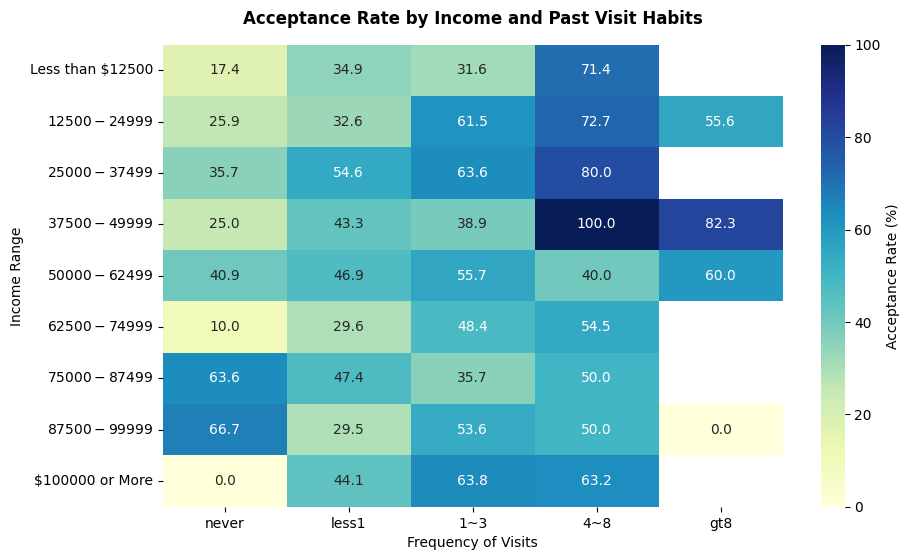

In [73]:
plt.figure(figsize=(10, 6))
sns.heatmap(income_vs_frequency, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Acceptance Rate (%)'})
plt.title("Acceptance Rate by Income and Past Visit Habits", weight='bold', pad=15)
plt.ylabel('Income Range')
plt.xlabel('Frequency of Visits')
plt.show()

I foud this chart very helpful in quantifying the impact of frequency vs income and clearly seeing some trends that now seem intuitive. Here are my observations:

1. **Frequency dominates income**

  * Across all income groups, there is a sharper uptick (represented by darker coloring). Lower-income frequent diners use the coupon because it makes their regular habit affordable; middle-income frequent diners use it as a standard perk.
  * At income `37500 - $49999` x `4~8`, the acceptance rate is **100%**!!
  * Interestingly, the acceptance dips a bit for medium level incomes and then increases again for high-income (`$100k or more`(

2. **"Never-wents" have high acceptance rate!**

  * This data confirms one of my initial hypotheses; the acceptance rate of coupons was high __even when frequency was low__. This can reduce the financial burden but also allows people to try out a new place without risk. Very often when I go out, I am wary of trying expensive places because I don't want to pay extra to find out the food wasn't good!
  * This is especially true in the mid-tier income brackets `"$75000  - $87499"` and  `"$87500 - $99999"`, where the acceptance rate reaches 63.6% and 66.7%

3. **Outlier: High-income never-wents**

  * I thought this was very interesting; high-income earners who never go to high-end restaurants, have a **0.00%** acceptance rate. Maybe this signals the hyper-focused wealth builder who does not consider it worth their time and moeny to go to these establishements even with a coupon?

Now I will investigate the time of day parameter, the next one in my initial list.

In [74]:
costly_restaurants_df['time'].unique()

array(['6PM', '7AM', '10AM', '10PM', '2PM'], dtype=object)

I think a `scatterplot` is a good choice to visualize this data. I can convert the string times to 24h numerical times and use `groupby` to find the acceptance rates.

In [75]:
time_24h_map = {'7AM': 7, '10AM': 10, '2PM': 14, '6PM': 18, '10PM': 22}

In [76]:
# Calculate the mean acceptance rate per time slot
time_acceptance = (
    costly_restaurants_df.groupby("time")["AcceptedCoupon_Raw"]
    .mean()
    .reset_index()
)

time_acceptance["Acceptance Rate (%)"] = (
    time_acceptance["AcceptedCoupon_Raw"] * 100
).round(2)
time_acceptance["time_24h"] = time_acceptance["time"].map(time_24h_map)

# Sort by the numerical values
time_agg = time_acceptance.sort_values(by="time_24h")

# reorder columns for visibility
time_agg_reordered = time_agg[
    ["time", "time_24h", "AcceptedCoupon_Raw", "Acceptance Rate (%)"]
]
time_agg_reordered


,time,time_24h,AcceptedCoupon_Raw,Acceptance Rate (%)
4,7AM,7,0.402439,40.24
0,10AM,10,0.607477,60.75
2,2PM,14,0.548571,54.86
3,6PM,18,0.502717,50.27
1,10PM,22,0.338936,33.89


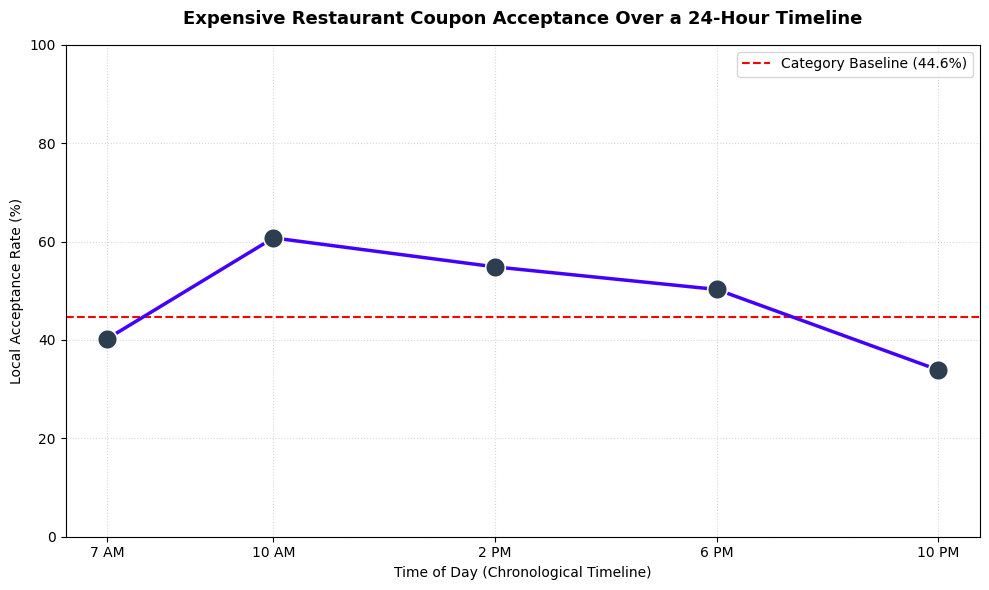

In [77]:
plt.figure(figsize=(10, 6))

# create scatter plot
sns.scatterplot(
    data=time_agg_reordered,
    x="time_24h",
    y="Acceptance Rate (%)",
    color="#2c3e50",  # Dark charcoal for high contrast contrast markers
    s=200,            # Prominent visual scale
    zorder=3,
)

# join the points
sns.lineplot(
    data=time_agg_reordered,
    x="time_24h",
    y="Acceptance Rate (%)",
    color="#4400FF", # a purplish blue
    linewidth=2.5,
    zorder=2,
)


# Add labels at the correct time slots
plt.xticks(
    ticks=[7, 10, 14, 18, 22],
    labels=["7 AM", "10 AM", "2 PM", "6 PM", "10 PM"],
)

# Other labels
plt.title(
    "Expensive Restaurant Coupon Acceptance Over a 24-Hour Timeline",
    weight="bold",
    fontsize=13,
    pad=15,
)
plt.xlabel("Time of Day (Chronological Timeline)")
plt.ylabel("Local Acceptance Rate (%)")


# We can also add a baseline acceptance for all expensive restaurant
plt.axhline(
    44.6,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Category Baseline (44.6%)",
    zorder=1,
)

plt.ylim(0, 100)  # Keep the full 0-100% scale context visible
plt.grid(axis="both", linestyle=":", alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

I found this chart interesting as well since it points out what seems to be an error in my judgment of what the `time` column was representing. I assumed it was when the coupon was used but judging from this chart I can think of 2 explanations:

1. the `time` param still means what I think it does, which means that people are more likely to use the coupon for breakfast `7AM - 10AM` than later in the day. This seems unlikely to me.

2. the `time` param means when was the coupon **delivered**. If it's delivered early in the day, perhaps users can make plans for an expensive time out.

If the observation 2 is correct, it actually does confirm my hypothesis in a roundabout way - people are more likely to use the coupon when they have a proper lead-up time to know they have the coupon available and if it's later in the day, they may alerady have made plans. So the coupon is unlikely to be used earlier in the day.

As a bonus I still want to check out if the passengers made a difference to this as well. If my previous theory is right, then sending a coupon earlier in the day is better for married couples and families so that they can plan out their day accordingly and go for a nice dinner or meal at a later time (another day) depending on the coupon expiry.

In [78]:
# Group by time AND passenger
social_acceptance = (
    costly_restaurants_df.groupby(["time", "passanger"])["AcceptedCoupon_Raw"]
    .mean()
    .reset_index()
)

social_acceptance["Acceptance Rate (%)"] = (
    social_acceptance["AcceptedCoupon_Raw"] * 100
).round(2)
social_acceptance["time_24h"] = social_acceptance["time"].map(time_24h_map)

# sort
social_agg = social_acceptance.sort_values(by="time_24h")

# reorganize for readability

social_agg_sorted = social_agg.sort_values(by=["time_24h", "passanger"])
print(social_agg_sorted)

    time  passanger  AcceptedCoupon_Raw  Acceptance Rate (%)  time_24h
11   7AM      Alone            0.402439                40.24         7
0   10AM    Partner            0.607477                60.75        10
5    2PM  Friend(s)            0.508475                50.85        14
6    2PM     Kid(s)            0.500000                50.00        14
7    2PM    Partner            0.800000                80.00        14
8    6PM      Alone            0.500000                50.00        18
9    6PM  Friend(s)            0.400000                40.00        18
10   6PM     Kid(s)            0.555556                55.56        18
1   10PM      Alone            0.365741                36.57        22
2   10PM  Friend(s)            0.388889                38.89        22
3   10PM     Kid(s)            0.277228                27.72        22
4   10PM    Partner            0.000000                 0.00        22


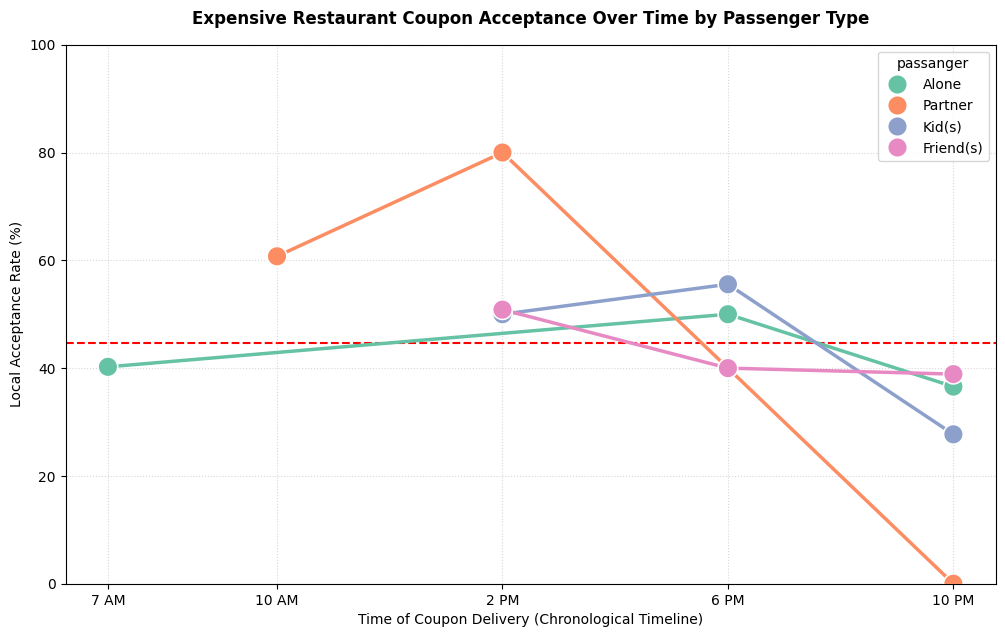

In [79]:
# Reuse the prior figure
plt.figure(figsize=(12, 7))

# Add hue="passanger" to split the line plot
sns.lineplot(
    data=social_agg,
    x="time_24h",
    y="Acceptance Rate (%)",
    hue="passanger",
    palette="Set2",
    linewidth=2.5,
    legend=False,
    zorder=2,
)

# 3. Add hue="passanger" to split the scatter plot
sns.scatterplot(
    data=social_agg,
    x="time_24h",
    y="Acceptance Rate (%)",
    hue="passanger",
    palette="Set2",
    s=200,
    zorder=3,
)

# Re add baseline and ticks for the relevant spots
plt.axhline(44.6, color="red", linestyle="--", linewidth=1.5, label="Category Baseline (44.6%)", zorder=1)
plt.xticks(ticks=[7, 10, 14, 18, 22], labels=["7 AM", "10 AM", "2 PM", "6 PM", "10 PM"])

# Label
plt.title("Expensive Restaurant Coupon Acceptance Over Time by Passenger Type", weight="bold", pad=15)
plt.xlabel("Time of Coupon Delivery (Chronological Timeline)")
plt.ylabel("Local Acceptance Rate (%)")
plt.ylim(0, 100)
plt.grid(axis="both", linestyle=":", alpha=0.5)

The data confirms some of my hypotheses:

1. Generally, **earlier coupons = more acceptance**

  * This is especially true for couples; earlier coupons are more likely to be accepted when a `partner` is present, going from `60%` to `80%` from `10AM` to `2PM` before crashing to `0%` by `10PM`
  * `Friends` follows a similar pattern but have a higher acceptance rate even later in the evening; as expected, they may decide to go for a night-out together and can make spontaneous plans.
  * Other categories also show this but at different times. `Single`s and Families with `kids` spike at around `6PM` ,
  * Note that from our initial data it also looks `Kids` and `Friends` were also not given coupons earlier than `2PM`

### Conclusion

From my observations, I developed a few simple new strategies for boosting our `Restaurant(20-50)` acceptance rate; additionally, I have some ideas of where to **avoid** spending time and energy with the coupons knowing they are more likely to be rejected. These are (ordered from higher to lower priority):

1. Target the high-frequency restaurant goers, regardless of income level. Acceptance rates are extremely strong for four or more visits, ranging from 70 to 100% depending on the income level.
2. Target mid-to-higher-income brackets if they have never gone to that restaurant before, capturing the 'aspirational spender' looking to try a premium spot with low financial risk. Acceptance levels here range in 60-70%. However, there is no point pursuing high-income "never-goers".
3. Get the coupons out earlier in the day across all categories. However, for last-minute plans, target `Singles` as they may go out by themselves or with friends. If we could somehow target friend groups live, that would be good as well to boost late-night acceptances.

   For families and married couples, the perfect time seems to fall between `10AM` and `2PM`, with acceptance rate rising to `80%`. This may also benefit the other categories so we should explore that as well who did not get a chance to receive earlier in the day coupons based on the provided data. We can also save ourselves frome expending energy sending coupons for married and family categories past `6PM`; single and friend groups on the other hand stay steady, close to the baseline acceptance rate, with the lowest being 38%.